In [1]:
import jsonlines
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jsonlines
from cattrs import unstructure
from dataclasses import dataclass, field
from itertools import combinations

from scheduler.entities import RunningTask, Task, Node, Edge, NetworkTopology
from scheduler.load_info import load_nodes, load_edges, load_tasks, build_task_graph

# Generating Synthetic Data

Experimenting with creating synthetic metrics for assigned tasks. Basically, generating somewhat plausible time series for CPU, memory, etc (simulate running jobs on a cluster).

0.13831199165325153 0.01093584607400225 2533.664345390965


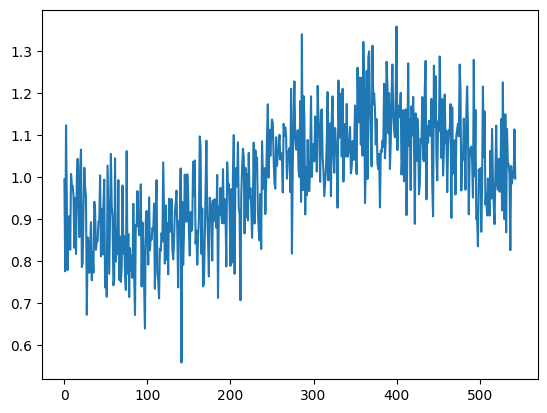

In [30]:
rng = np.random.default_rng()

size = 544

period = rng.uniform(0, 10 * size)
a = rng.uniform(0.05, 0.95)
b = 2 * np.pi / period
c = rng.uniform(0, 10 * size)

print(a, b, c)

scale_factor = 1 + a * np.sin( b * (np.arange(size) - c) )
noise = rng.normal(loc=0, scale=0.1, size=size)

cpu = scale_factor + noise

plt.plot(cpu)

# Fake Network Control Data

Experimenting with generating different aspects of army control demo data (network topo, nodes, task requests, etc).

## Exploring Current Data

Just seeing what the network topo in the CSV looks like.

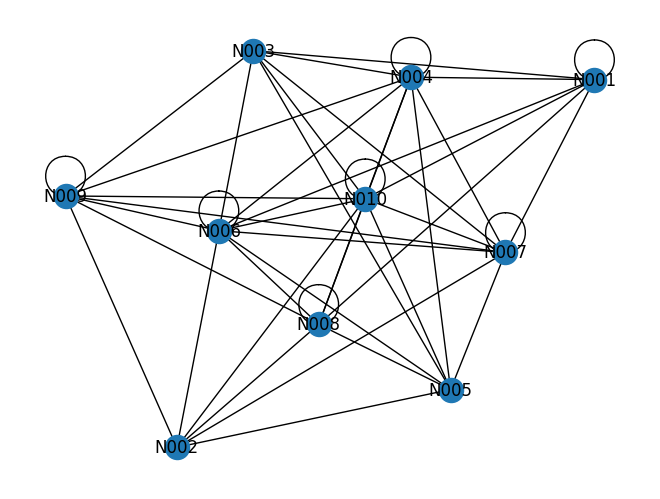

In [30]:
node_path = "dummy_data/nodes.csv"
edge_path = "dummy_data/edges.csv"
nodes = load_nodes(node_path)
edges = load_edges(edge_path)
network = NetworkTopology(nodes.values(), edges.values())
nx.draw(network._graph, with_labels=True)

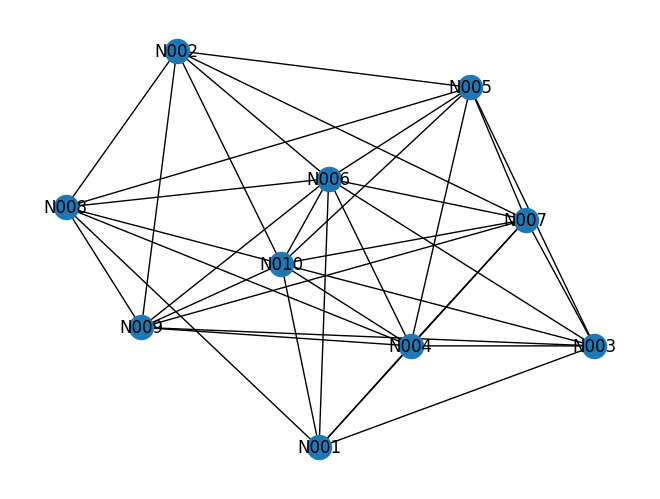

In [46]:
res = nx.Graph()
for n in network._graph.nodes:
    res.add_node(n)
for n1, n2 in combinations(res.nodes, 2):
    path = nx.shortest_path(network._graph, n1, n2)
    nx.add_path(res, path)
nx.draw(res, with_labels=True)

## Generate Fake Network Topo

Generate a fake compute cluster, with node and link information.

31.0


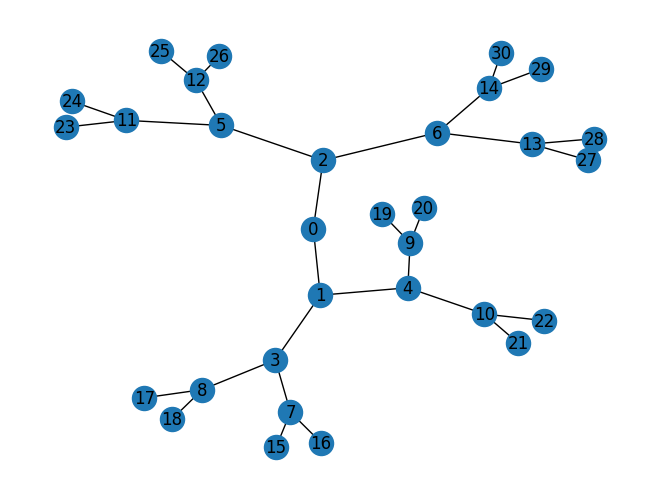

In [2]:
# Generate basic topology for network. Sparse to mimic edge network.
r = 2
h = 4
num_nodes = (r ** (h + 1) - 1) / (r - 1)
print(num_nodes)

graph = nx.balanced_tree(r, h)
nx.draw(graph, with_labels=True)

In [3]:
# Generate node specs.
import random

# Each node can be one of 4 tiers of CPU + memory.
cpu_options = [2, 4, 8, 16]
memory_options = [8, 16, 32, 64]

cpu_specs = random.choices(cpu_options, weights=reversed(cpu_options), k=len(graph.nodes))
mem_specs = [4 * cpu for cpu in cpu_specs]

gen_nodes = []
for i, (cpu, memory) in enumerate(zip(cpu_specs, mem_specs)):
    n_id = f'N{i:03}'
    node = Node(node_id=n_id, cpu_capacity=cpu, memory_capacity=memory)
    gen_nodes.append(node)
    print(node)

Node(node_id='N000', cpu_capacity=8, memory_capacity=32, used_cpu=0.0, used_memory=0.0)
Node(node_id='N001', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N002', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N003', cpu_capacity=16, memory_capacity=64, used_cpu=0.0, used_memory=0.0)
Node(node_id='N004', cpu_capacity=4, memory_capacity=16, used_cpu=0.0, used_memory=0.0)
Node(node_id='N005', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N006', cpu_capacity=4, memory_capacity=16, used_cpu=0.0, used_memory=0.0)
Node(node_id='N007', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N008', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N009', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N010', cpu_capacity=4, memory_capacity=16, used_cpu=0.0, used_memory=0.0)
Node(node_id='N011', cpu_capacity=2, 

In [4]:
# Generate edges.
bandwidth = 100 # Set to fixed mbps for now.

gen_edges = []
for u, v in graph.edges:
    u_id = f'N{u:03}'
    v_id = f'N{v:03}'
    edge = Edge(edge_id=(u_id, v_id), capacity=bandwidth)
    gen_edges.append(edge)
    print(edge)

Edge(edge_id=('N000', 'N001'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N000', 'N002'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N003'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N004'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N005'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N006'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N007'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N008'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N009'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N010'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N011'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N012'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N013'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N014'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N015'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N0

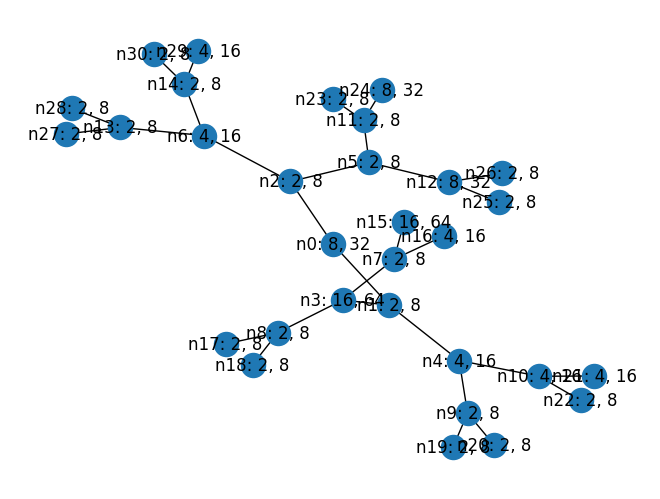

In [5]:
# View generated topo with associated CPU/memory count.
gen_graph = graph.copy(as_view=False)
nx.set_node_attributes(gen_graph, {i: node for i, node in enumerate(gen_nodes)}, 'data')
labels = {i: f'n{i}: {node.cpu_capacity}, {node.memory_capacity}' for i, node in enumerate(gen_nodes)}
nx.draw(gen_graph, with_labels=True, labels=labels)

## Generating Task Information

Tasks can either be independent, or have communication dependencies between each other, so we must generate various task "graphs".

Num Tasks: 62


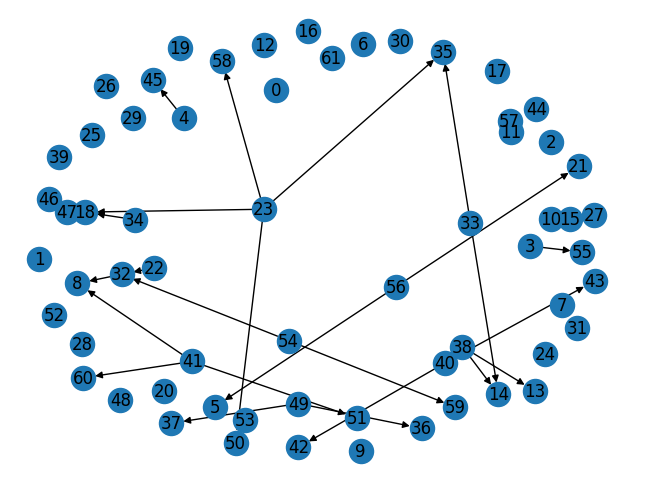

In [20]:
# Generate task graphs.
num_tasks = int(num_nodes * 2)
print(f'Num Tasks: {num_tasks}')
# Number of edges should scale linearly with nodes -> maintains sparsity.
frac = (num_tasks / num_tasks ** 2) / 2
task_graph = nx.fast_gnp_random_graph(num_tasks, p=frac, directed=True)
nx.draw(task_graph, with_labels=True)

In [21]:
# Visualize different task graphs.
comps = list(nx.weakly_connected_components(task_graph))
num_comps = 0
for comp in comps:
    num_comps += 1
    print(comp)
num_comps

{0}
{1}
{2}
{3, 55}
{4, 45}
{56, 21, 5}
{6}
{7}
{32, 8, 41, 51, 22, 54, 59, 60}
{9}
{10, 27, 15}
{57, 11}
{12}
{33, 34, 35, 38, 13, 14, 47, 50, 18, 53, 23, 58}
{16}
{17}
{19}
{20}
{24}
{25}
{26}
{28}
{29}
{30}
{31}
{49, 36, 37}
{39}
{40, 42, 43}
{44}
{46}
{48}
{52}
{61}


33

In [22]:
import time


def make_peer_bws(graph: nx.DiGraph, node: int):
    peer_bws = {}
    rng = np.random.default_rng()
    for n in task_graph.neighbors(node):
        peer_id = f'T{n:03}'
        peer_bws[peer_id] = rng.uniform(1, 100)
    return peer_bws


def process_comp(task_graph: nx.DiGraph, comp: list[int], arrival_time: int = 0, stdev=1) -> list[Task]:
    rng = np.random.default_rng()
    tasks = []
    for v in comp:
        task_id = f'T{v:03}'
        
        cpu = np.clip(rng.rayleigh(4), 0, 16)
        memory = np.clip(rng.rayleigh(16), 0, 64)
        offset = max(0, rng.normal(loc=arrival_time, scale=stdev))
        peer_bws = make_peer_bws(task_graph, v)
        duration = rng.uniform(3 * 60, 15 * 60)
                                 
        task = Task(
            task_id=task_id,
            arrival_offset_s=offset,
            initial_cpu=cpu,
            initial_memory=memory,
            peer_bandwidths=peer_bws,
            duration_s=duration
        )
        tasks.append(task)
    return tasks

In [23]:
# Generate task specs for task graph.
interval = 30
rng = np.random.default_rng()

tasks = []
comp_idx = []
curr_time = 0
for i, comp in enumerate(comps):
    curr_time += rng.uniform(0, 2 * interval)
    out = process_comp(task_graph, comp, arrival_time=curr_time, stdev=interval / 2)
    tasks += out
    comp_idx += [i] * len(out)
    print(f'COMP {i}:\n')
    for task in out:
        print(task)
    print()

COMP 0:

Task(task_id='T000', arrival_offset_s=25.97496095085793, duration_s=181.6935617504451, initial_cpu=np.float64(2.4175359243850996), initial_memory=np.float64(9.163194472383013), peer_bandwidths={})

COMP 1:

Task(task_id='T001', arrival_offset_s=52.538161652990055, duration_s=637.0367241287827, initial_cpu=np.float64(3.4908787113710655), initial_memory=np.float64(6.285448414858003), peer_bandwidths={})

COMP 2:

Task(task_id='T002', arrival_offset_s=93.67506906670324, duration_s=302.0631787644438, initial_cpu=np.float64(7.465889036599003), initial_memory=np.float64(14.641285847781385), peer_bandwidths={})

COMP 3:

Task(task_id='T003', arrival_offset_s=121.53125624035908, duration_s=688.8528328549493, initial_cpu=np.float64(2.7117278792594854), initial_memory=np.float64(24.67808985455125), peer_bandwidths={'T055': 99.80812390186352})
Task(task_id='T055', arrival_offset_s=129.69604250647302, duration_s=748.5211498585724, initial_cpu=np.float64(5.910790061987981), initial_memory=

In [24]:
# Visualize arrival times for different tasks in the format: task id, task graph (component) idx, arrival time offset (s)
for comp_i, t in sorted(zip(comp_idx, tasks), key=lambda x: x[1].arrival_offset_s):
    print(t.task_id, comp_i, t.arrival_offset_s)

T000 0 25.97496095085793
T001 1 52.538161652990055
T002 2 93.67506906670324
T004 4 119.78368691661733
T003 3 121.53125624035908
T055 3 129.69604250647302
T045 4 134.86124642670168
T021 5 191.07429251817334
T005 5 205.98933924741988
T006 6 219.98375502166377
T056 5 226.62773560707765
T007 7 262.2571275639786
T032 8 275.6484492667854
T060 8 293.25061480848706
T022 8 307.60719067437634
T041 8 312.577878058342
T054 8 313.54849692925507
T008 8 318.7529406444582
T009 9 322.3894116855826
T051 8 327.603699862065
T059 8 327.62970361448174
T057 11 385.1234093385831
T011 11 395.1601945876665
T027 10 403.88162966513613
T010 10 404.35529444511917
T015 10 406.5138620217689
T047 13 444.93466608278277
T012 12 446.93000305397356
T038 13 449.1289426795288
T035 13 453.2854939806153
T058 13 458.68783362348455
T018 13 459.40341374380995
T016 14 459.680606640134
T013 13 462.8212175540629
T014 13 471.92933654481965
T050 13 473.57434526903694
T053 13 475.83485529399775
T034 13 476.44557974334873
T017 15 481.2

## Serialize Data

Save as JSONL so we can have nested data structures.

In [25]:
def serialize_jsonl(data: list, path: str):
    with jsonlines.open(path, 'w') as writer:
        if data:
            data_type = type(data[0])
            data = unstructure(data, list[data_type])
            writer.write_all(data)

In [26]:
task_gen_path = 'tasks.jsonl'
sorted_data = sorted(tasks, key=lambda x: x.arrival_offset_s)
serialize_jsonl(sorted_data, task_gen_path)

In [15]:
node_gen_path = 'nodes.jsonl'
serialize_jsonl(gen_nodes, node_gen_path)

In [16]:
edge_gen_path = 'edges.jsonl'
serialize_jsonl(gen_edges, edge_gen_path)